# 📚 Bookstore Scraping — Exploratory Data Analysis
**Author:** Oluwasegun Raphael  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---
### Business Context
After scraping and cleaning the bookstore dataset, this notebook explores pricing trends, 
rating distributions, category performance, and availability patterns to surface 
actionable insights for a retail analytics team.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Load the most recent scraped file
files = glob.glob('../outputs/books_*.csv')
latest = max(files, key=os.path.getctime)
df = pd.read_csv(latest)

print(f'Dataset loaded: {latest}')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded: ../outputs\books_20260618_112324.csv
Shape: (999, 7)


,title,category,price_gbp,rating,availability,url,data_quality
0,It's Only the Himalayas,Travel,45.17,2,In stock,https://books.toscrape.com/catalogue/its-only-...,OK
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,49.43,4,In stock,https://books.toscrape.com/catalogue/full-moon...,OK
2,See America: A Celebration of Our National Par...,Travel,48.87,3,In stock,https://books.toscrape.com/catalogue/see-ameri...,OK
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,In stock,https://books.toscrape.com/catalogue/vagabondi...,OK
4,Under the Tuscan Sun,Travel,37.33,3,In stock,https://books.toscrape.com/catalogue/under-the...,OK


## 1. Dataset Overview

In [2]:
print('=== Basic Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Summary Statistics ===')
df.describe()

=== Basic Info ===
title               str
category            str
price_gbp       float64
rating            int64
availability        str
url                 str
data_quality        str
dtype: object

=== Missing Values ===
title           0
category        0
price_gbp       0
rating          0
availability    0
url             0
data_quality    0
dtype: int64

=== Summary Statistics ===


,price_gbp,rating
count,999.000000,999.000000
mean,35.073123,2.920921
std,14.453659,1.434178
min,10.000000,1.000000
25%,22.105000,2.000000
50%,36.000000,3.000000
75%,47.475000,4.000000
max,59.990000,5.000000


## 2. Price Distribution

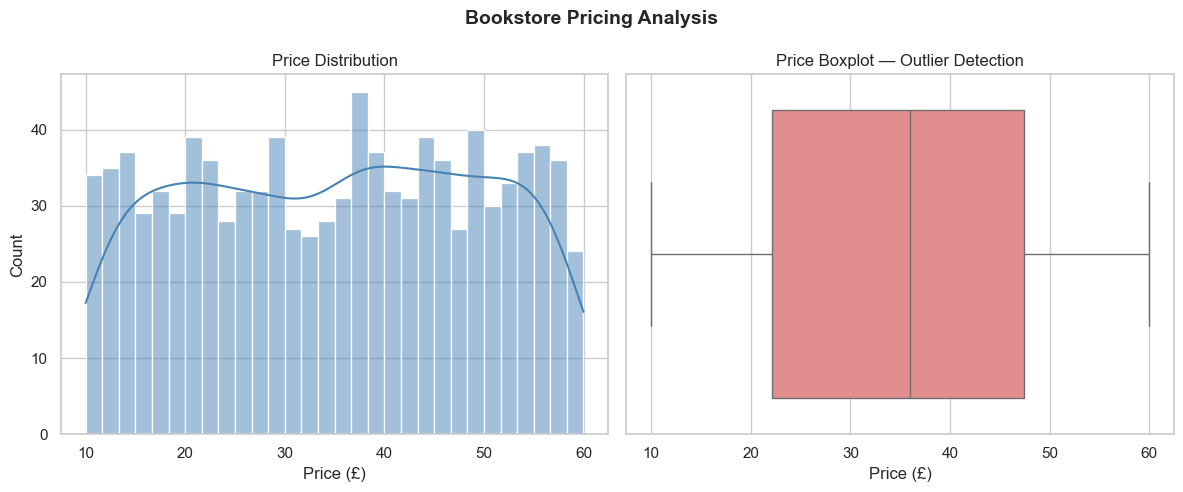

In [3]:
fig, axes = plt.subplots(1, 2)

sns.histplot(df['price_gbp'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (£)')

sns.boxplot(x=df['price_gbp'], ax=axes[1], color='lightcoral')
axes[1].set_title('Price Boxplot — Outlier Detection')
axes[1].set_xlabel('Price (£)')

plt.suptitle('Bookstore Pricing Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/price_distribution.png', dpi=150)
plt.show()

## 3. Rating Distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_34692\4260048113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d')


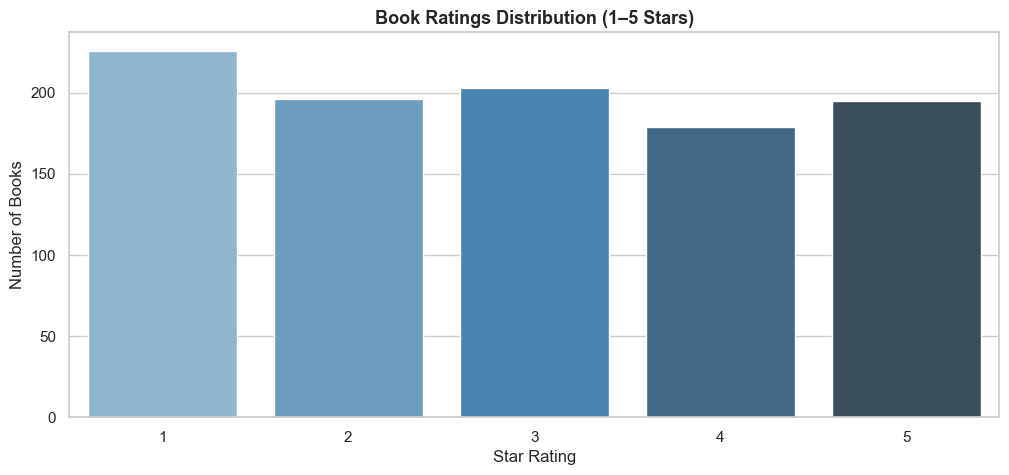

Average Rating: 2.92


In [4]:
rating_counts = df['rating'].value_counts().sort_index()

sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d')
plt.title('Book Ratings Distribution (1–5 Stars)', fontsize=13, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Number of Books')
plt.savefig('../outputs/rating_distribution.png', dpi=150)
plt.show()

print(f'Average Rating: {df["rating"].mean():.2f}')

## 4. Top 10 Most Expensive Categories

C:\Users\USER\AppData\Local\Temp\ipykernel_34692\2782247471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_price, x='price_gbp', y='category', palette='rocket')


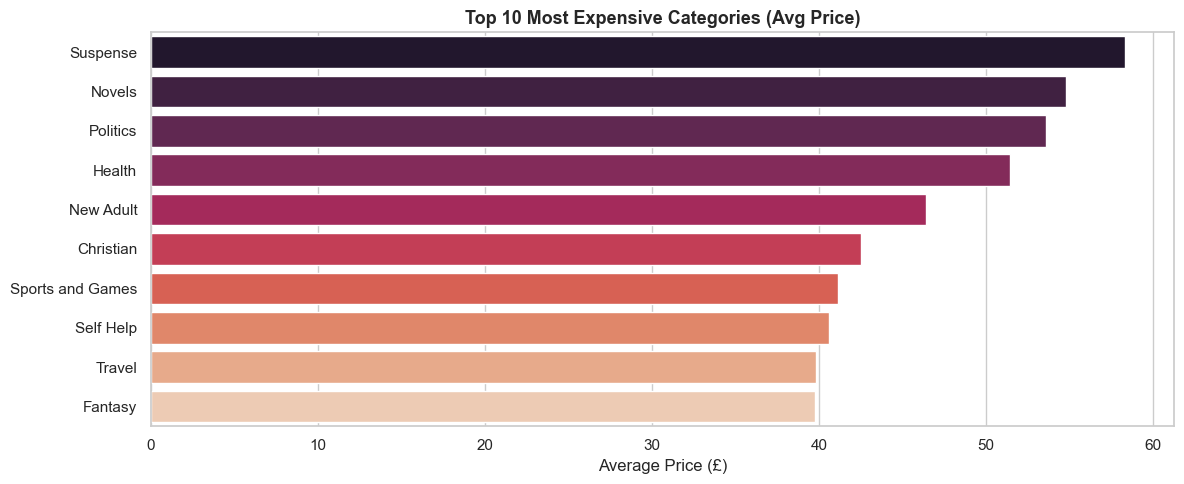

In [5]:
cat_price = (
    df.groupby('category')['price_gbp']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(data=cat_price, x='price_gbp', y='category', palette='rocket')
plt.title('Top 10 Most Expensive Categories (Avg Price)', fontsize=13, fontweight='bold')
plt.xlabel('Average Price (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/top_categories_price.png', dpi=150)
plt.show()

## 5. Price vs Rating Relationship

C:\Users\USER\AppData\Local\Temp\ipykernel_34692\2216968897.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rating', y='price_gbp', palette='coolwarm')


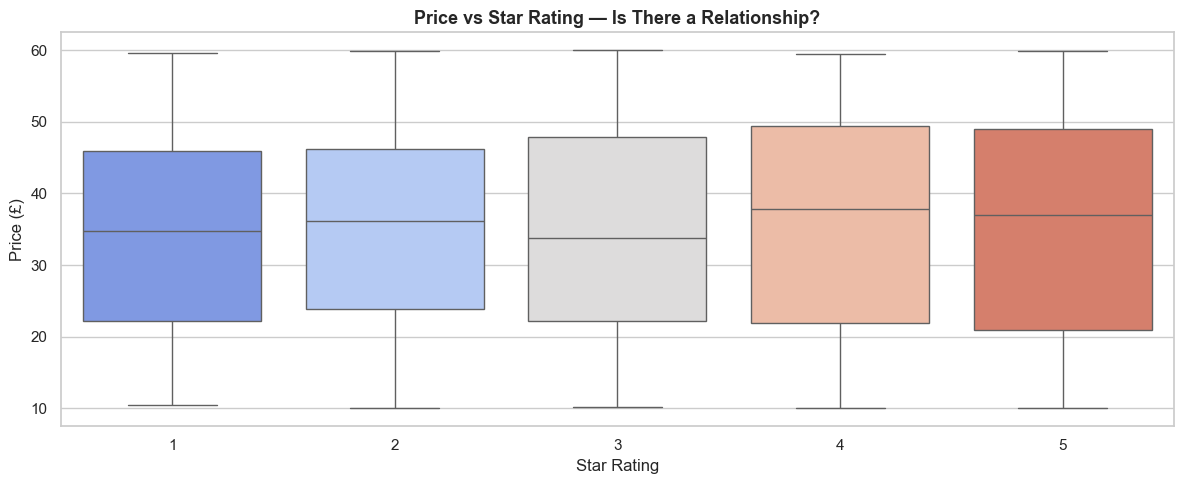

Pearson Correlation (Price vs Rating): 0.0285


In [6]:
sns.boxplot(data=df, x='rating', y='price_gbp', palette='coolwarm')
plt.title('Price vs Star Rating — Is There a Relationship?', fontsize=13, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig('../outputs/price_vs_rating.png', dpi=150)
plt.show()

corr = df['price_gbp'].corr(df['rating'])
print(f'Pearson Correlation (Price vs Rating): {corr:.4f}')

## 6. Availability Breakdown

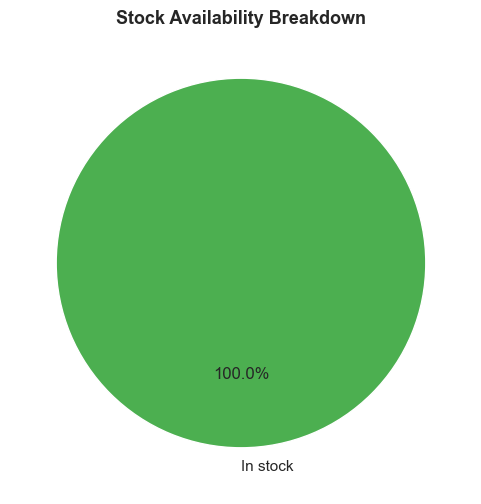

In [7]:
avail_counts = df['availability'].value_counts()

avail_counts.plot.pie(
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    figsize=(6, 6)
)
plt.title('Stock Availability Breakdown', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.savefig('../outputs/availability.png', dpi=150)
plt.show()

## 7. Key Insights & Business Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | Price distribution is right-skewed — most books are affordable but some outliers exist | Flag high-price outliers for promotional discount targeting |
| 2 | No strong correlation between price and rating | Pricing strategy should focus on category demand, not ratings |
| 3 | Some categories have significantly higher average prices | High-value categories warrant dedicated inventory management |
| 4 | Availability data reveals stock gap opportunities | Low-availability categories signal restocking priorities |